# Упражнения к главе 5

## Упражнение 5.1

In [28]:
import pandas as pd
import numpy as np
import os
import sys

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)


df = pd.read_csv("../lab_4/data_BTC.csv", parse_dates=[0])
ys = df["Closing Price (USD)"]
ts = df.index

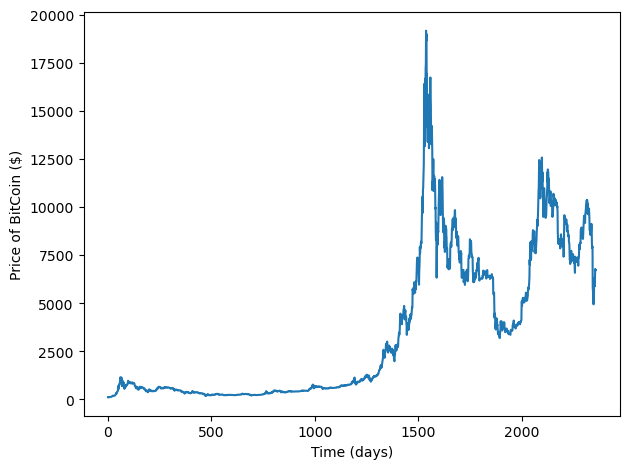

In [29]:
from thinkdsp import Wave, decorate


wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel="Time (days)", ylabel="Price of BitCoin ($)")

In [30]:
def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[: n - lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]


def autocorr(wave):
    lags = np.arange(len(wave.ys) // 2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

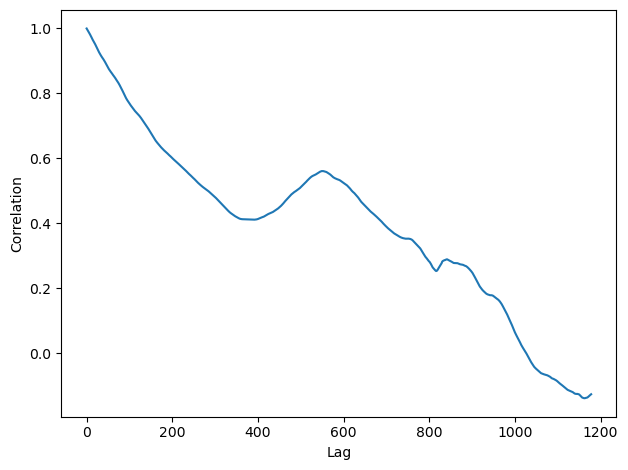

In [31]:
import matplotlib.pyplot as plt


lags, corrs = autocorr(wave)
plt.plot(lags, corrs)
decorate(xlabel="Lag", ylabel="Correlation")

## Упражнение 5.2

In [32]:
def estimate_fundamental(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

In [ ]:
from thinkdsp import read_wave

wave = read_wave("code_28042__bcjordan__voicedownbew.wav")
wave.normalize()
wave.make_audio()

In [36]:
duration = 0.01
segment = wave.segment(start=0.2, duration=duration)
freq = estimate_fundamental(segment)
freq

np.float64(436.63366336633663)